In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Loading dataset...
Found 3999 images: [0, 1, 2, 3, 4, 7, 8, 9, 10, 14]...
Successfully loaded 3999 images with annotations
Expression labels range: 0 to 7
Valence range: -0.987 to 0.982
Arousal range: -0.667 to 0.984
After filtering: 3999 valid samples
Expression class distribution:
  Neutral: 500
  Happy: 500
  Sad: 500
  Surprise: 500
  Fear: 500
  Disgust: 500
  Anger: 500
  Contempt: 499
Training set: 2399 samples
Validation set: 800 samples
Test set: 800 samples

Training ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model Summary for ResNet50:
Total parameters: 24,901,770
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 600s 8s/step - arousal_loss: 0.6075 - arousal_mae: 0.6574 - expression_accuracy: 0.1064 - expression_loss: 2.3960 - loss: 2.9514 - valence_loss: 0.5032 - valence_mae: 0.5705 - val_arousal_loss: 0.1418 - val_arousal_mae: 0.3261 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0842 - val_loss: 2.2674 - val_valence_loss: 0.2246 - val_valence_mae: 0.3864 

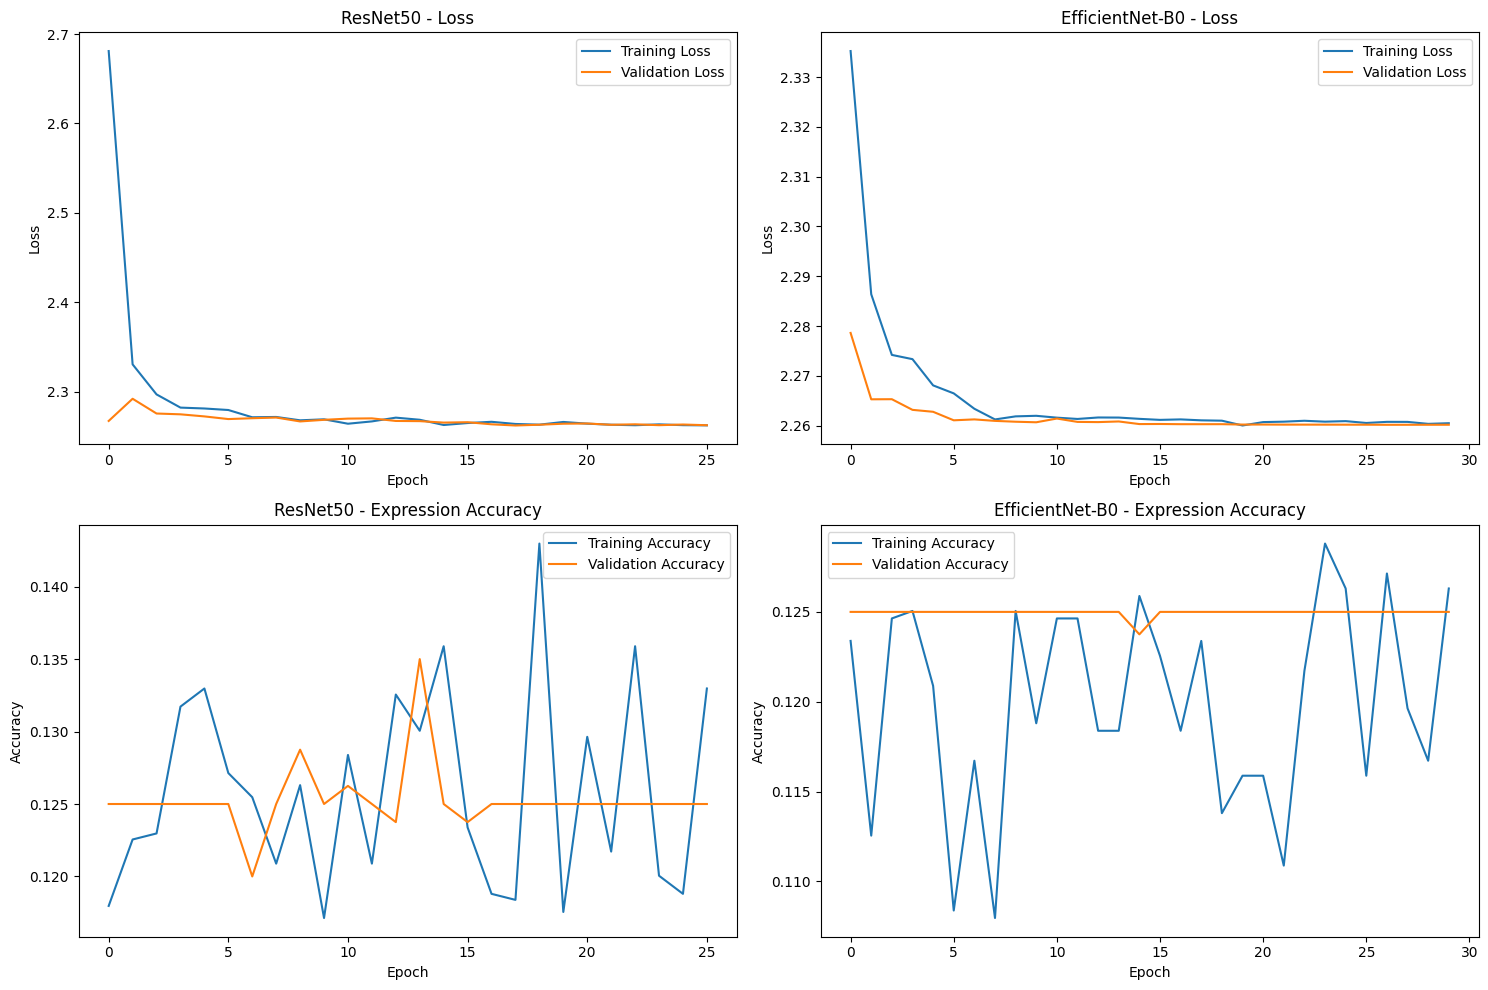


Model Comparison:
                 accuracy  f1_score  kappa  val_rmse  aro_rmse  val_corr  \
ResNet50            0.125    0.0278    0.0    0.4715    0.3808    0.0149   
EfficientNet-B0     0.125    0.0278    0.0    0.4705    0.3740       NaN   

                 aro_corr  val_sagr  aro_sagr  val_ccc  aro_ccc  
ResNet50           0.0609    0.6715    0.7592   0.0001   0.0027  
EfficientNet-B0    0.0000    0.6716    0.7598   0.0000   0.0000  


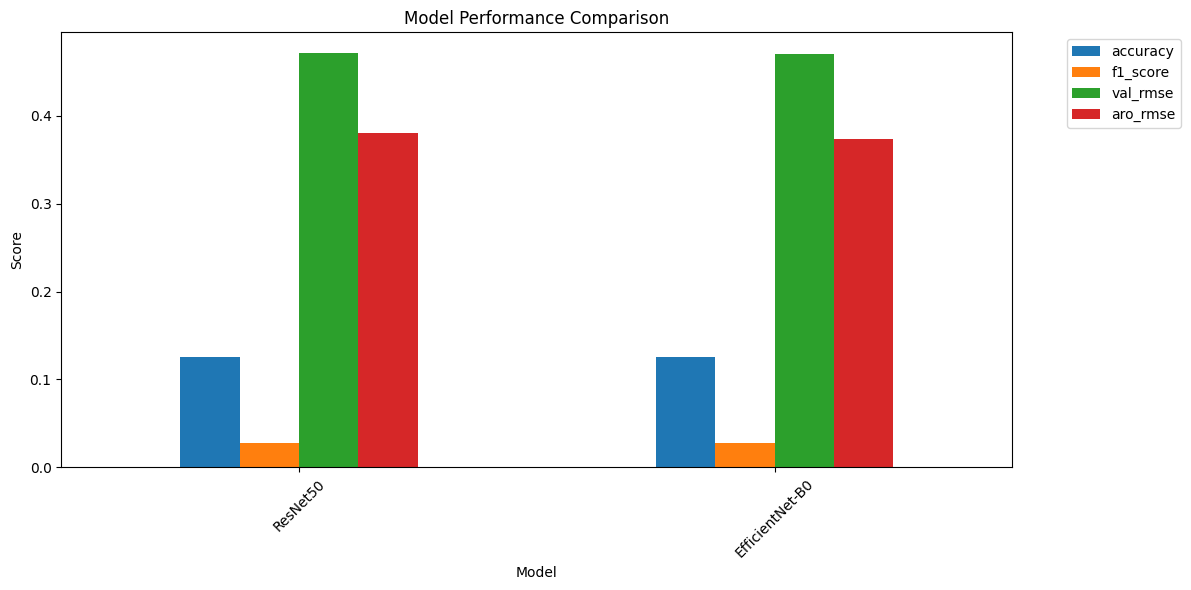


Experiment completed successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os
import glob
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class FacialExpressionDataset:
    """Dataset class for loading and preprocessing facial expression data"""

    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.images = []
        self.expressions = []
        self.valence = []
        self.arousal = []
        self.emotion_labels = {
            0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Surprise',
            4: 'Fear', 5: 'Disgust', 6: 'Anger', 7: 'Contempt'
        }

    def load_data(self):
        """Load images and annotations from the dataset"""
        print("Loading dataset...")

        # Get image and annotation paths
        image_path = os.path.join(self.dataset_path, 'images')
        annotation_path = os.path.join(self.dataset_path, 'annotations')

        # Get all image numbers (assuming images are named as numbers without extension or with extensions)
        image_files = []
        for ext in ['', '.jpg', '.jpeg', '.png']:
            pattern = os.path.join(image_path, f'*{ext}')
            image_files.extend(glob.glob(pattern))

        # Extract image numbers from filenames
        image_numbers = []
        for img_file in image_files:
            basename = os.path.basename(img_file)
            # Remove extension if present
            img_num = os.path.splitext(basename)[0]
            try:
                image_numbers.append(int(img_num))
            except ValueError:
                continue

        image_numbers = sorted(list(set(image_numbers)))
        print(f"Found {len(image_numbers)} images: {image_numbers[:10]}..." if len(image_numbers) > 10 else f"Found {len(image_numbers)} images: {image_numbers}")

        # Load images and corresponding annotations
        loaded_count = 0
        for img_num in image_numbers:
            # Try different image extensions
            img_loaded = False
            for ext in ['', '.jpg', '.jpeg', '.png']:
                img_file = os.path.join(image_path, f'{img_num}{ext}')
                if os.path.exists(img_file):
                    img = cv2.imread(img_file)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (224, 224))
                        self.images.append(img)
                        img_loaded = True
                        break

            if not img_loaded:
                continue

            # Load corresponding annotations
            exp_file = os.path.join(annotation_path, f'{img_num}_exp.npy')
            val_file = os.path.join(annotation_path, f'{img_num}_val.npy')
            aro_file = os.path.join(annotation_path, f'{img_num}_aro.npy')

            try:
                # Load expression (should be a single integer)
                if os.path.exists(exp_file):
                    exp_data = np.load(exp_file, allow_pickle=True)
                    exp_value = exp_data.item() if exp_data.ndim == 0 else exp_data[0]
                    self.expressions.append(int(exp_value))
                else:
                    self.expressions.append(0)  # Default to neutral

                # Load valence (should be a single float)
                if os.path.exists(val_file):
                    val_data = np.load(val_file, allow_pickle=True)
                    val_value = val_data.item() if val_data.ndim == 0 else val_data[0]
                    self.valence.append(float(val_value))
                else:
                    self.valence.append(0.0)

                # Load arousal (should be a single float)
                if os.path.exists(aro_file):
                    aro_data = np.load(aro_file, allow_pickle=True)
                    aro_value = aro_data.item() if aro_data.ndim == 0 else aro_data[0]
                    self.arousal.append(float(aro_value))
                else:
                    self.arousal.append(0.0)

                loaded_count += 1

            except Exception as e:
                print(f"Error loading annotations for image {img_num}: {e}")
                # Remove the last added image if annotations failed
                if len(self.images) > 0:
                    self.images.pop()

        # Convert to numpy arrays with proper dtypes
        self.images = np.array(self.images, dtype=np.float32)
        self.expressions = np.array(self.expressions, dtype=np.int32)
        self.valence = np.array(self.valence, dtype=np.float32)
        self.arousal = np.array(self.arousal, dtype=np.float32)

        print(f"Successfully loaded {len(self.images)} images with annotations")
        print(f"Expression labels range: {np.min(self.expressions)} to {np.max(self.expressions)}")
        print(f"Valence range: {np.min(self.valence):.3f} to {np.max(self.valence):.3f}")
        print(f"Arousal range: {np.min(self.arousal):.3f} to {np.max(self.arousal):.3f}")

        return self.images, self.expressions, self.valence, self.arousal

    def preprocess_data(self):
        """Preprocess the data"""
        # Normalize images to [0, 1]
        self.images = self.images.astype(np.float32) / 255.0

        # Filter out uncertain and no-face categories (where valence/arousal = -2)
        valid_indices = (self.valence != -2.0) & (self.arousal != -2.0)

        self.images = self.images[valid_indices]
        self.expressions = self.expressions[valid_indices]
        self.valence = self.valence[valid_indices]
        self.arousal = self.arousal[valid_indices]

        print(f"After filtering: {len(self.images)} valid samples")

        # Check class distribution
        unique, counts = np.unique(self.expressions, return_counts=True)
        print("Expression class distribution:")
        for exp_id, count in zip(unique, counts):
            print(f"  {self.emotion_labels.get(exp_id, f'Unknown({exp_id})')}: {count}")

        return self.images, self.expressions, self.valence, self.arousal

class CustomMetrics:
    """Custom metrics for continuous domain evaluation"""

    @staticmethod
    def sagr(y_true, y_pred):
        """Sign Agreement Metric"""
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()

        signs_true = np.sign(y_true)
        signs_pred = np.sign(y_pred)
        sign_agreement = np.mean(signs_true == signs_pred)

        # Penalize incorrect signs more heavily
        mse = np.mean((y_true - y_pred) ** 2)
        sagr_score = sign_agreement - 0.1 * mse
        return sagr_score

    @staticmethod
    def ccc(y_true, y_pred):
        """Concordance Correlation Coefficient"""
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()

        if len(y_true) == 0 or len(y_pred) == 0:
            return 0.0

        pearson_corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else 0.0
        mean_true = np.mean(y_true)
        mean_pred = np.mean(y_pred)
        var_true = np.var(y_true)
        var_pred = np.var(y_pred)

        if var_true == 0 or var_pred == 0:
            return 0.0

        ccc = (2 * pearson_corr * np.sqrt(var_true) * np.sqrt(var_pred)) / \
              (var_true + var_pred + (mean_true - mean_pred) ** 2)
        return ccc if not np.isnan(ccc) else 0.0

class CNNModel:
    """Base CNN Model class"""

    def __init__(self, model_name, input_shape=(224, 224, 3), num_classes=8):
        self.model_name = model_name
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.history = None

    def build_model(self):
        """Build the CNN model"""
        pass

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        optimizer = optimizers.Adam(learning_rate=learning_rate)

        # Multi-output model (expression classification + valence/arousal regression)
        self.model.compile(
            optimizer=optimizer,
            loss={
                'expression': 'sparse_categorical_crossentropy',
                'valence': 'mse',
                'arousal': 'mse'
            },
            metrics={
                'expression': ['accuracy'],
                'valence': ['mae'],
                'arousal': ['mae']
            },
            loss_weights={'expression': 1.0, 'valence': 0.5, 'arousal': 0.5}
        )

    def prepare_targets(self, y_data):
        """Prepare targets for multi-output model"""
        if isinstance(y_data, dict):
            return {
                'expression': y_data['expression'],
                'valence': y_data['valence'],
                'arousal': y_data['arousal']
            }
        else:
            # Assume y_data is a tuple (expressions, valence, arousal)
            return {
                'expression': y_data[0],
                'valence': y_data[1],
                'arousal': y_data[2]
            }

    def train(self, X_train, y_train, X_val, y_val, epochs=30, batch_size=32):
        """Train the model"""
        # Prepare targets
        train_targets = self.prepare_targets(y_train)
        val_targets = self.prepare_targets(y_val)

        # Data augmentation (reduced for stability)
        datagen = ImageDataGenerator(
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=True,
            zoom_range=0.1,
            fill_mode='nearest'
        )

        # Callbacks
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=8,
                restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=4,
                min_lr=1e-7
            )
        ]

        # Train model
        self.history = self.model.fit(
            X_train, train_targets,
            validation_data=(X_val, val_targets),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test):
        """Evaluate the model"""
        test_targets = self.prepare_targets(y_test)
        predictions = self.model.predict(X_test)

        if isinstance(predictions, list):
            exp_pred = predictions[0]
            val_pred = predictions[1]
            aro_pred = predictions[2]
        else:
            exp_pred = predictions
            val_pred = None
            aro_pred = None

        results = {}

        # Classification metrics
        exp_pred_classes = np.argmax(exp_pred, axis=1)
        exp_true = test_targets['expression']

        results['accuracy'] = accuracy_score(exp_true, exp_pred_classes)
        results['f1_score'] = f1_score(exp_true, exp_pred_classes, average='weighted')
        results['kappa'] = cohen_kappa_score(exp_true, exp_pred_classes)

        # Regression metrics
        if val_pred is not None and aro_pred is not None:
            val_true = test_targets['valence']
            aro_true = test_targets['arousal']

            val_pred_flat = val_pred.flatten()
            aro_pred_flat = aro_pred.flatten()

            results['val_rmse'] = np.sqrt(mean_squared_error(val_true, val_pred_flat))
            results['aro_rmse'] = np.sqrt(mean_squared_error(aro_true, aro_pred_flat))

            # Handle correlation calculation safely
            if len(val_true) > 1 and np.var(val_true) > 0 and np.var(val_pred_flat) > 0:
                results['val_corr'] = pearsonr(val_true, val_pred_flat)[0]
            else:
                results['val_corr'] = 0.0

            if len(aro_true) > 1 and np.var(aro_true) > 0 and np.var(aro_pred_flat) > 0:
                results['aro_corr'] = pearsonr(aro_true, aro_pred_flat)[0]
            else:
                results['aro_corr'] = 0.0

            results['val_sagr'] = CustomMetrics.sagr(val_true, val_pred_flat)
            results['aro_sagr'] = CustomMetrics.sagr(aro_true, aro_pred_flat)
            results['val_ccc'] = CustomMetrics.ccc(val_true, val_pred_flat)
            results['aro_ccc'] = CustomMetrics.ccc(aro_true, aro_pred_flat)

        return results, predictions

class ResNetModel(CNNModel):
    """ResNet50 model implementation"""

    def __init__(self, input_shape=(224, 224, 3), num_classes=8):
        super().__init__("ResNet50", input_shape, num_classes)

    def build_model(self):
        # Base ResNet50 model
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=self.input_shape
        )

        # Freeze base model layers initially
        base_model.trainable = False

        # Input layer
        inputs = keras.Input(shape=self.input_shape)

        # Base model
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)

        # Shared dense layers
        shared = layers.Dense(512, activation='relu')(x)
        shared = layers.Dropout(0.3)(shared)

        # Expression classification head
        expression_output = layers.Dense(256, activation='relu')(shared)
        expression_output = layers.Dropout(0.3)(expression_output)
        expression_output = layers.Dense(self.num_classes, activation='softmax', name='expression')(expression_output)

        # Valence regression head
        valence_output = layers.Dense(128, activation='relu')(shared)
        valence_output = layers.Dropout(0.3)(valence_output)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(valence_output)

        # Arousal regression head
        arousal_output = layers.Dense(128, activation='relu')(shared)
        arousal_output = layers.Dropout(0.3)(arousal_output)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(arousal_output)

        # Create model
        self.model = keras.Model(inputs, [expression_output, valence_output, arousal_output])

class EfficientNetModel(CNNModel):
    """EfficientNet-B0 model implementation"""

    def __init__(self, input_shape=(224, 224, 3), num_classes=8):
        super().__init__("EfficientNet-B0", input_shape, num_classes)

    def build_model(self):
        # Base EfficientNet-B0 model
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=self.input_shape
        )

        # Freeze base model layers initially
        base_model.trainable = False

        # Input layer
        inputs = keras.Input(shape=self.input_shape)

        # Base model
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)

        # Shared dense layers
        shared = layers.Dense(512, activation='relu')(x)
        shared = layers.Dropout(0.3)(shared)

        # Expression classification head
        expression_output = layers.Dense(256, activation='relu')(shared)
        expression_output = layers.Dropout(0.3)(expression_output)
        expression_output = layers.Dense(self.num_classes, activation='softmax', name='expression')(expression_output)

        # Valence regression head
        valence_output = layers.Dense(128, activation='relu')(shared)
        valence_output = layers.Dropout(0.3)(valence_output)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(valence_output)

        # Arousal regression head
        arousal_output = layers.Dense(128, activation='relu')(shared)
        arousal_output = layers.Dropout(0.3)(arousal_output)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(arousal_output)

        # Create model
        self.model = keras.Model(inputs, [expression_output, valence_output, arousal_output])

class ExperimentRunner:
    """Main experiment runner class"""

    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.dataset = FacialExpressionDataset(dataset_path)
        self.models = {}
        self.results = {}

    def prepare_data(self):
        """Prepare and split the data"""
        # Load and preprocess data
        X, expressions, valence, arousal = self.dataset.load_data()
        X, expressions, valence, arousal = self.dataset.preprocess_data()

        # Convert to proper data types
        X = X.astype(np.float32)
        expressions = expressions.astype(np.int32)
        valence = valence.astype(np.float32)
        arousal = arousal.astype(np.float32)

        # Split data with proper stratification
        X_temp, X_test, exp_temp, exp_test, val_temp, val_test, aro_temp, aro_test = train_test_split(
            X, expressions, valence, arousal,
            test_size=0.2, random_state=42, stratify=expressions
        )

        X_train, X_val, exp_train, exp_val, val_train, val_val, aro_train, aro_val = train_test_split(
            X_temp, exp_temp, val_temp, aro_temp,
            test_size=0.25, random_state=42, stratify=exp_temp
        )

        # Prepare target dictionaries
        y_train = {
            'expression': exp_train,
            'valence': val_train,
            'arousal': aro_train
        }

        y_val = {
            'expression': exp_val,
            'valence': val_val,
            'arousal': aro_val
        }

        y_test = {
            'expression': exp_test,
            'valence': val_test,
            'arousal': aro_test
        }

        print(f"Training set: {X_train.shape[0]} samples")
        print(f"Validation set: {X_val.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")

        return X_train, X_val, X_test, y_train, y_val, y_test

    def run_experiments(self):
        """Run experiments with both models"""
        # Prepare data
        X_train, X_val, X_test, y_train, y_val, y_test = self.prepare_data()

        # Initialize models
        self.models['ResNet50'] = ResNetModel()
        self.models['EfficientNet-B0'] = EfficientNetModel()

        # Train and evaluate each model
        for model_name, model in self.models.items():
            print(f"\n{'='*50}")
            print(f"Training {model_name}")
            print(f"{'='*50}")

            # Build and compile model
            model.build_model()
            model.compile_model(learning_rate=0.001)

            print(f"Model Summary for {model_name}:")
            print(f"Total parameters: {model.model.count_params():,}")

            # Train model
            history = model.train(X_train, y_train, X_val, y_val, epochs=30, batch_size=32)

            # Evaluate model
            results, predictions = model.evaluate(X_test, y_test)
            self.results[model_name] = results

            # Print results
            print(f"\nResults for {model_name}:")
            for metric, value in results.items():
                if isinstance(value, float):
                    print(f"{metric}: {value:.4f}")
                else:
                    print(f"{metric}: {value}")

    def plot_training_history(self):
        """Plot training history for all models"""
        if not any(model.history for model in self.models.values()):
            print("No training history available for plotting.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        model_idx = 0
        for model_name, model in self.models.items():
            if model.history is None:
                continue

            col = model_idx % 2

            # Plot loss
            axes[0, col].plot(model.history.history['loss'], label='Training Loss')
            axes[0, col].plot(model.history.history['val_loss'], label='Validation Loss')
            axes[0, col].set_title(f'{model_name} - Loss')
            axes[0, col].set_xlabel('Epoch')
            axes[0, col].set_ylabel('Loss')
            axes[0, col].legend()

            # Plot accuracy
            axes[1, col].plot(model.history.history['expression_accuracy'], label='Training Accuracy')
            axes[1, col].plot(model.history.history['val_expression_accuracy'], label='Validation Accuracy')
            axes[1, col].set_title(f'{model_name} - Expression Accuracy')
            axes[1, col].set_xlabel('Epoch')
            axes[1, col].set_ylabel('Accuracy')
            axes[1, col].legend()

            model_idx += 1

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

    def compare_models(self):
        """Compare model performance"""
        if not self.results:
            print("No results available for comparison.")
            return

        comparison_df = pd.DataFrame(self.results).T

        print("\nModel Comparison:")
        print("="*80)
        print(comparison_df.round(4))

        # Plot comparison for available metrics
        metrics_to_plot = ['accuracy', 'f1_score', 'val_rmse', 'aro_rmse']
        available_metrics = [m for m in metrics_to_plot if m in comparison_df.columns]

        if available_metrics:
            fig, ax = plt.subplots(figsize=(12, 6))
            comparison_df[available_metrics].plot(kind='bar', ax=ax)
            ax.set_title('Model Performance Comparison')
            ax.set_ylabel('Score')
            ax.set_xlabel('Model')
            ax.tick_params(axis='x', rotation=45)
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
            plt.show()

# Main execution
if __name__ == "__main__":
    # Set dataset path - CHANGE THIS TO YOUR DATASET PATH
    dataset_path = "/content/drive/My Drive/Dataset"

    # Create experiment runner
    experiment = ExperimentRunner(dataset_path)

    try:
        # Run experiments
        experiment.run_experiments()

        # Plot results
        experiment.plot_training_history()
        experiment.compare_models()

        print("\nExperiment completed successfully!")

    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()